# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [2]:
corpus = '''
Tujhe Sochta Hoon main shaam o subah
Iss se zyada tujhe aur chahoon toh kya
Tere hi khayalon mein dooba raha
Iss se zyada tujhe aur chahoon toh kya

Bas saare gham mein jaana, sang hoon tere
Har ek mausam me jaana, sang hoon tere
Aaa aa aaa…. sang hoon tere
Aaa aa aaa…. sang hoon tere
Aaa aa aa…. sang hoon tere

Meri dhadkano mein hi teri sada
Iss qadar tu meri rooh mein bas gaya
Teri yaadon se kab raha main judaa
Waqt se pooch le, waqt mera gawaah

Bas sare gham mein jaana, sang hoon tere
Har ek mausam me jaana, sang hoon tere
Ab itne imtehaa bhi naa le mere
Aaa aa aaa…. sang hoon tere
Aaa aa aaa…. sang hoon tere
Aaa aa aa…. sang hoon tere
'''
print(corpus)


Tujhe Sochta Hoon main shaam o subah
Iss se zyada tujhe aur chahoon toh kya
Tere hi khayalon mein dooba raha
Iss se zyada tujhe aur chahoon toh kya

Bas saare gham mein jaana, sang hoon tere
Har ek mausam me jaana, sang hoon tere
Aaa aa aaa…. sang hoon tere
Aaa aa aaa…. sang hoon tere
Aaa aa aa…. sang hoon tere

Meri dhadkano mein hi teri sada
Iss qadar tu meri rooh mein bas gaya
Teri yaadon se kab raha main judaa
Waqt se pooch le, waqt mera gawaah

Bas sare gham mein jaana, sang hoon tere
Har ek mausam me jaana, sang hoon tere
Ab itne imtehaa bhi naa le mere
Aaa aa aaa…. sang hoon tere
Aaa aa aaa…. sang hoon tere
Aaa aa aa…. sang hoon tere



# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [3]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 57
X shape: (113, 7)
y shape: (113,)


In [4]:
tokenizer.word_index


{'hoon': 1,
 'tere': 2,
 'sang': 3,
 'aaa': 4,
 'aa': 5,
 'mein': 6,
 'se': 7,
 'jaana': 8,
 'aaa…': 9,
 'tujhe': 10,
 'iss': 11,
 'bas': 12,
 'main': 13,
 'zyada': 14,
 'aur': 15,
 'chahoon': 16,
 'toh': 17,
 'kya': 18,
 'hi': 19,
 'raha': 20,
 'gham': 21,
 'har': 22,
 'ek': 23,
 'mausam': 24,
 'me': 25,
 'aa…': 26,
 'meri': 27,
 'teri': 28,
 'waqt': 29,
 'le': 30,
 'sochta': 31,
 'shaam': 32,
 'o': 33,
 'subah': 34,
 'khayalon': 35,
 'dooba': 36,
 'saare': 37,
 'dhadkano': 38,
 'sada': 39,
 'qadar': 40,
 'tu': 41,
 'rooh': 42,
 'gaya': 43,
 'yaadon': 44,
 'kab': 45,
 'judaa': 46,
 'pooch': 47,
 'mera': 48,
 'gawaah': 49,
 'sare': 50,
 'ab': 51,
 'itne': 52,
 'imtehaa': 53,
 'bhi': 54,
 'naa': 55,
 'mere': 56}

In [5]:
sequences = tokenizer.texts_to_sequences([corpus])
sequences

[[10,
  31,
  1,
  13,
  32,
  33,
  34,
  11,
  7,
  14,
  10,
  15,
  16,
  17,
  18,
  2,
  19,
  35,
  6,
  36,
  20,
  11,
  7,
  14,
  10,
  15,
  16,
  17,
  18,
  12,
  37,
  21,
  6,
  8,
  3,
  1,
  2,
  22,
  23,
  24,
  25,
  8,
  3,
  1,
  2,
  4,
  5,
  9,
  3,
  1,
  2,
  4,
  5,
  9,
  3,
  1,
  2,
  4,
  5,
  26,
  3,
  1,
  2,
  27,
  38,
  6,
  19,
  28,
  39,
  11,
  40,
  41,
  27,
  42,
  6,
  12,
  43,
  28,
  44,
  7,
  45,
  20,
  13,
  46,
  29,
  7,
  47,
  30,
  29,
  48,
  49,
  12,
  50,
  21,
  6,
  8,
  3,
  1,
  2,
  22,
  23,
  24,
  25,
  8,
  3,
  1,
  2,
  51,
  52,
  53,
  54,
  55,
  30,
  56,
  4,
  5,
  9,
  3,
  1,
  2,
  4,
  5,
  9,
  3,
  1,
  2,
  4,
  5,
  26,
  3,
  1,
  2]]

# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [6]:
rnn_model = Sequential([
    Embedding(total_words, 128, input_length=max_len-1),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=200, verbose=0)
print("Vanilla RNN training completed")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [7]:
lstm_model = Sequential([
    Embedding(total_words, 128, input_length=max_len-1),
    LSTM(128),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=200, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [8]:
gru_model = Sequential([
    Embedding(total_words, 128, input_length=max_len-1),
    GRU(128),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=200, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

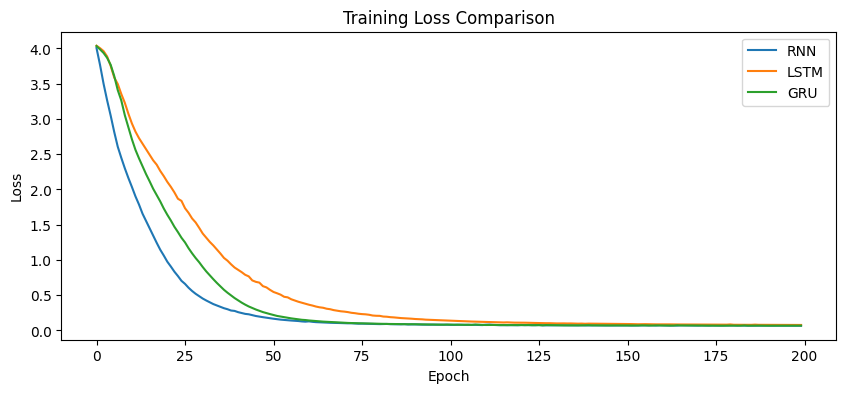

In [9]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [10]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [11]:
print("RNN :", generate_text(rnn_model, "deep learning", 10))
print("LSTM:", generate_text(lstm_model, "deep learning", 10))
print("GRU :", generate_text(gru_model, "deep learning", 10))

RNN : deep learning se sochta hoon main shaam o subah shaam jaana sang
LSTM: deep learning saare saare gham mein jaana sang hoon tere tere tere
GRU : deep learning sare gham mein jaana sang hoon tere tere tere subah


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**